In [1]:
import pandas as pd

df = pd.read_csv("big_startup_secsees_dataset.csv")
df.head()

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1.0,NaN,1/5/2015,1/5/2015
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2.0,9/4/2014,3/1/2014,10/14/2014
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1.0,NaN,1/30/2014,1/30/2014
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1.0,1/1/2007,3/19/2008,3/19/2008
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1.0,1/1/2010,7/24/2014,7/24/2014


In [2]:
df.drop(['permalink', 'name', 'homepage_url'], axis=1, inplace=True)

In [3]:
df = df.dropna(subset=['status'])

In [4]:
df['status'] = df['status'].map({
    'operating': 1,
    'acquired': 1,
    'closed': 0
})

In [5]:
df['funding_total_usd'] = df['funding_total_usd'].replace('-', 0)
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')
df['funding_total_usd'] = df['funding_total_usd'].fillna(df['funding_total_usd'].median())

In [6]:
df['category_list'] = df['category_list'].fillna("Unknown")
df['country_code'] = df['country_code'].fillna("Unknown")
df['state_code'] = df['state_code'].fillna("Unknown")
df['region'] = df['region'].fillna("Unknown")
df['city'] = df['city'].fillna("Unknown")

In [7]:
df.drop(['region', 'city'], axis=1, inplace=True)

In [8]:
top_cat = df['category_list'].value_counts().nlargest(20).index
df['category_list'] = df['category_list'].apply(lambda x: x if x in top_cat else "Other")

In [9]:
df = pd.get_dummies(df, columns=['category_list','country_code','state_code'], drop_first=True)

In [10]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19335 entries, 0 to 19334
Columns: 388 entries, funding_total_usd to state_code_Z7
dtypes: bool(382), float64(3), object(3)
memory usage: 7.9+ MB


,0
funding_total_usd,0
status,537
funding_rounds,1
founded_at,4491
first_funding_at,9
...,...
state_code_X5,0
state_code_Y4,0
state_code_Y6,0
state_code_Z1,0


In [11]:
df = df.dropna(subset=['status'])

In [12]:
df['status'].value_counts()

,count
status,
1.0,17004
0.0,1794


In [13]:
df['status'] = df['status'].map({
    'operating': 1,
    'acquired': 1,
    'closed': 0
})

In [14]:
df.isnull().sum()
df['status'].value_counts()

,count
status,


In [15]:
df['status'].unique()

array([nan])

In [16]:
df = df.dropna(subset=['status'])

In [17]:
df['status'] = df['status'].map({
    'operating': 1,
    'acquired': 1,
    'closed': 0
})

In [18]:
df['status'].value_counts()
df['status'].isnull().sum()

np.int64(0)

In [19]:
df['status'].value_counts()

,count
status,


In [20]:
df = pd.read_csv("big_startup_secsees_dataset.csv")

df = df.dropna(subset=['status'])

df['status'] = df['status'].map({
    'operating': 1,
    'acquired': 1,
    'closed': 0
})

In [21]:
df['status'].value_counts()

,count
status,
1.0,17004
0.0,1794


In [22]:
df.isnull().sum()

,0
permalink,0
name,0
homepage_url,1460
category_list,894
funding_total_usd,0
status,537
country_code,1911
state_code,2373
region,2217
city,2218


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19335 entries, 0 to 19334
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   permalink          19335 non-null  object 
 1   name               19335 non-null  object 
 2   homepage_url       17875 non-null  object 
 3   category_list      18441 non-null  object 
 4   funding_total_usd  19335 non-null  object 
 5   status             18798 non-null  float64
 6   country_code       17424 non-null  object 
 7   state_code         16962 non-null  object 
 8   region             17118 non-null  object 
 9   city               17117 non-null  object 
 10  funding_rounds     19334 non-null  float64
 11  founded_at         14844 non-null  object 
 12  first_funding_at   19326 non-null  object 
 13  last_funding_at    19334 non-null  object 
dtypes: float64(2), object(12)
memory usage: 2.1+ MB


In [24]:
import numpy as np

np.isinf(df.select_dtypes(include=[np.number])).sum().sum()

np.int64(0)

In [25]:
print("SHAPE:\n", df.shape)
print("\nMISSING VALUES:\n", df.isnull().sum().sort_values(ascending=False))
print("\nDATA TYPES:\n", df.dtypes)
print("\nSTATUS VALUE COUNTS:\n", df['status'].value_counts(dropna=False))
print("\nDUPLICATES:\n", df.duplicated().sum())

SHAPE:
 (19335, 14)

MISSING VALUES:
 founded_at           4491
state_code           2373
city                 2218
region               2217
country_code         1911
homepage_url         1460
category_list         894
status                537
first_funding_at        9
funding_rounds          1
last_funding_at         1
funding_total_usd       0
permalink               0
name                    0
dtype: int64

DATA TYPES:
 permalink             object
name                  object
homepage_url          object
category_list         object
funding_total_usd     object
status               float64
country_code          object
state_code            object
region                object
city                  object
funding_rounds       float64
founded_at            object
first_funding_at      object
last_funding_at       object
dtype: object

STATUS VALUE COUNTS:
 status
1.0    17004
0.0     1794
NaN      537
Name: count, dtype: int64

DUPLICATES:
 0


In [26]:
df = df.dropna(subset=['status'])

In [ ]:
df['status'] = df['status'].astype(int)

In [27]:
df.drop(['permalink', 'name', 'homepage_url'], axis=1, inplace=True)

In [29]:
df['funding_total_usd'] = df['funding_total_usd'].replace('-', 0)
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')
df['funding_total_usd'] = df['funding_total_usd'].fillna(df['funding_total_usd'].median())


In [30]:
df['category_list'] = df['category_list'].fillna("Unknown")
df['country_code'] = df['country_code'].fillna("Unknown")
df['state_code'] = df['state_code'].fillna("Unknown")
df['region'] = df['region'].fillna("Unknown")
df['city'] = df['city'].fillna("Unknown")

In [31]:
df['funding_rounds'] = df['funding_rounds'].fillna(0).astype(int)

In [32]:
df.isnull().sum()
df.info()
df['status'].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 18798 entries, 0 to 19334
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   category_list      18798 non-null  object 
 1   funding_total_usd  18798 non-null  float64
 2   status             18798 non-null  float64
 3   country_code       18798 non-null  object 
 4   state_code         18798 non-null  object 
 5   region             18798 non-null  object 
 6   city               18798 non-null  object 
 7   funding_rounds     18798 non-null  int64  
 8   founded_at         14433 non-null  object 
 9   first_funding_at   18789 non-null  object 
 10  last_funding_at    18797 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 1.7+ MB


,count
status,
1.0,17004
0.0,1794


In [33]:
print("SHAPE:\n", df.shape)
print("\nMISSING VALUES:\n", df.isnull().sum().sort_values(ascending=False))
print("\nDATA TYPES:\n", df.dtypes)
print("\nSTATUS VALUE COUNTS:\n", df['status'].value_counts(dropna=False))
print("\nDUPLICATES:\n", df.duplicated().sum())

SHAPE:
 (18798, 11)

MISSING VALUES:
 founded_at           4365
first_funding_at        9
last_funding_at         1
status                  0
funding_total_usd       0
category_list           0
country_code            0
city                    0
region                  0
state_code              0
funding_rounds          0
dtype: int64

DATA TYPES:
 category_list         object
funding_total_usd    float64
status               float64
country_code          object
state_code            object
region                object
city                  object
funding_rounds         int64
founded_at            object
first_funding_at      object
last_funding_at       object
dtype: object

STATUS VALUE COUNTS:
 status
1.0    17004
0.0     1794
Name: count, dtype: int64

DUPLICATES:
 32


In [2]:
import pandas as pd

df = pd.read_csv("big_startup_secsees_dataset.csv")

In [3]:
df['first_funding_at'] = df['first_funding_at'].fillna(df['first_funding_at'].mode()[0])
df['last_funding_at'] = df['last_funding_at'].fillna(df['last_funding_at'].mode()[0])

In [4]:
df['status'] = df['status'].astype(int)

ValueError: invalid literal for int() with base 10: 'operating'

In [5]:
df['status'].value_counts()

,count
status,
operating,53034
closed,6238
acquired,5549
ipo,1547


In [6]:
df['status'] = df['status'].map({
    'operating': 1,
    'acquired': 1,
    'closed': 0
})

In [7]:
df['status'].value_counts(dropna=False)

,count
status,
1.0,58583
0.0,6238
NaN,1547


In [8]:
df = df.dropna(subset=['status'])

In [9]:
df['status'].value_counts(dropna=False)

,count
status,
1.0,58583
0.0,6238


In [10]:
df['status'] = df['status'].astype(int)

In [11]:
df['status'].dtype

dtype('int64')

In [12]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nStatus Counts:")
print(df['status'].value_counts())

Shape: (64821, 14)

Missing Values:
founded_at           14861
state_code            8480
region                7974
city                  7972
country_code          6918
homepage_url          5022
category_list         3135
name                     1
permalink                0
funding_total_usd        0
status                   0
funding_rounds           0
first_funding_at         0
last_funding_at          0
dtype: int64

Status Counts:
status
1    58583
0     6238
Name: count, dtype: int64


In [13]:
df.columns.tolist()

['permalink',
 'name',
 'homepage_url',
 'category_list',
 'funding_total_usd',
 'status',
 'country_code',
 'state_code',
 'region',
 'city',
 'funding_rounds',
 'founded_at',
 'first_funding_at',
 'last_funding_at']

In [14]:
df = df.drop(['permalink', 'name', 'homepage_url'], axis=1)

In [15]:
df['category_list'] = df['category_list'].fillna('Unknown')
df['country_code'] = df['country_code'].fillna('Unknown')
df['state_code'] = df['state_code'].fillna('Unknown')
df['region'] = df['region'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')

In [16]:
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')
df['first_funding_at'] = pd.to_datetime(df['first_funding_at'], errors='coerce')
df['last_funding_at'] = pd.to_datetime(df['last_funding_at'], errors='coerce')

In [17]:
current_year = 2026

df['company_age'] = current_year - df['founded_at'].dt.year

df['time_to_first_funding'] = (
    df['first_funding_at'] - df['founded_at']
).dt.days

df['funding_duration'] = (
    df['last_funding_at'] - df['first_funding_at']
).dt.days

In [18]:
df['company_age'] = df['company_age'].fillna(df['company_age'].median())
df['time_to_first_funding'] = df['time_to_first_funding'].fillna(df['time_to_first_funding'].median())
df['funding_duration'] = df['funding_duration'].fillna(df['funding_duration'].median())

In [19]:
df = df.drop(
    ['founded_at', 'first_funding_at', 'last_funding_at'],
    axis=1
)

In [20]:
top_cat = df['category_list'].value_counts().nlargest(20).index

df['category_list'] = df['category_list'].apply(
    lambda x: x if x in top_cat else 'Other'
)

In [21]:
top_country = df['country_code'].value_counts().nlargest(10).index

df['country_code'] = df['country_code'].apply(
    lambda x: x if x in top_country else 'Other'
)

In [22]:
top_state = df['state_code'].value_counts().nlargest(10).index

df['state_code'] = df['state_code'].apply(
    lambda x: x if x in top_state else 'Other'
)

In [23]:
df = df.drop(['region', 'city'], axis=1)

In [24]:
df = pd.get_dummies(
    df,
    columns=['category_list', 'country_code', 'state_code'],
    drop_first=True
)

In [25]:
print(df.shape)
print(df.isnull().sum().sum())
print(df.dtypes.value_counts())

(64821, 46)
0
bool       40
float64     3
int64       2
object      1
Name: count, dtype: int64


In [26]:
df.isnull().sum().sum()

np.int64(0)

In [27]:
print(df.shape)
print(df.dtypes.value_counts())
print(df['status'].value_counts())

(64821, 46)
bool       40
float64     3
int64       2
object      1
Name: count, dtype: int64
status
1    58583
0     6238
Name: count, dtype: int64


In [28]:
df.select_dtypes(include='object').columns

Index(['funding_total_usd'], dtype='object')

In [29]:
df['funding_total_usd'].head(10)

,funding_total_usd
0,10000000
1,700000
2,3406878
3,2000000
4,-
5,41250
6,762851
7,33600000
8,1150050
9,40000


In [30]:
df['funding_total_usd'].sample(10)

,funding_total_usd
36597,4000000
31346,20000
66358,15419877
27800,38500000
59880,13500000
46564,-
24517,100000
51292,9400000
25563,305000
57976,1500000


In [31]:
df['funding_total_usd'] = (
    df['funding_total_usd']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
    .replace('-', '0')
)

df['funding_total_usd'] = pd.to_numeric(
    df['funding_total_usd'],
    errors='coerce'
)

In [32]:
df['funding_total_usd'] = df['funding_total_usd'].fillna(
    df['funding_total_usd'].median()
)

In [33]:
print(df.dtypes.value_counts())
print(df['funding_total_usd'].dtype)
print(df.isnull().sum().sum())

bool       40
float64     4
int64       2
Name: count, dtype: int64
float64
0


In [35]:
df.to_csv("startup_clean_dataset.csv", index=False)

In [36]:
from google.colab import files

files.download("startup_clean_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import pandas as pd
import numpy as np

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

In [5]:
df = pd.read_csv("startup_clean_dataset.csv")

In [6]:
X = df.drop('status', axis=1)
y = df['status']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [9]:
y_pred_rf = rf.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8696490551484767

Classification Report:

              precision    recall  f1-score   support

           0       0.27      0.22      0.24      1248
           1       0.92      0.94      0.93     11717

    accuracy                           0.87     12965
   macro avg       0.60      0.58      0.59     12965
weighted avg       0.86      0.87      0.86     12965



In [11]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [12]:
y_pred_gb = gb.predict(X_test)

In [13]:
print("GB Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_gb))

GB Accuracy: 0.9037408407250289

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.04      0.08      1248
           1       0.91      1.00      0.95     11717

    accuracy                           0.90     12965
   macro avg       0.70      0.52      0.51     12965
weighted avg       0.87      0.90      0.87     12965



In [14]:
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("GB Accuracy:", accuracy_score(y_test, y_pred_gb))

RF Accuracy: 0.8696490551484767
GB Accuracy: 0.9037408407250289


In [15]:
import pickle

with open("startup_model.pkl", "wb") as f:
    pickle.dump(gb, f)

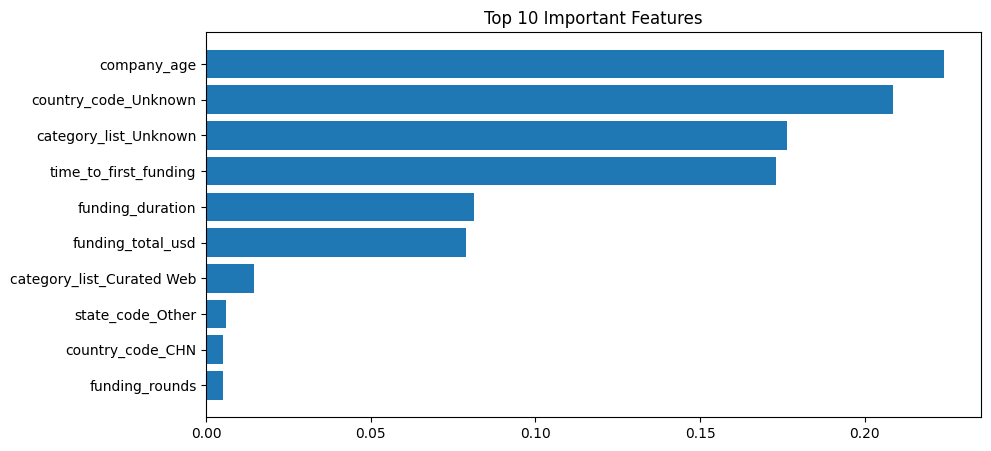

In [16]:
import matplotlib.pyplot as plt
import numpy as np

importances = gb.feature_importances_
features = X.columns

indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10,5))
plt.title("Top 10 Important Features")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.show()

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = gb.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[   54  1194]
 [   54 11663]]
              precision    recall  f1-score   support

           0       0.50      0.04      0.08      1248
           1       0.91      1.00      0.95     11717

    accuracy                           0.90     12965
   macro avg       0.70      0.52      0.51     12965
weighted avg       0.87      0.90      0.87     12965



In [18]:
from sklearn.metrics import roc_auc_score

print(roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]))

0.7667254036431833


In [19]:
import os

print(os.listdir())

['.config', 'startup_clean_dataset.csv', 'startup_model.pkl', 'big_startup_secsees_dataset.csv', 'sample_data']


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Accuracy: 0.8696490551484767
Precision: 0.9183145598664998
Recall: 0.9393189382947853
F1: 0.9286980001687621
ROC-AUC: 0.7091320850922285


In [21]:
gb_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall:", recall_score(y_test, gb_pred))
print("F1:", f1_score(y_test, gb_pred))
print("ROC-AUC:", roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]))

Accuracy: 0.9037408407250289
Precision: 0.9071323014700163
Recall: 0.9953913117692242
F1: 0.9492146170749572
ROC-AUC: 0.7667254036431833


In [22]:
from sklearn.metrics import confusion_matrix

print("RF Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nGB Matrix")
print(confusion_matrix(y_test, gb_pred))

RF Matrix
[[  269   979]
 [  711 11006]]

GB Matrix
[[   54  1194]
 [   54 11663]]


In [23]:
import time

start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

start = time.time()
gb.fit(X_train, y_train)
gb_time = time.time() - start

print("RF Training Time:", rf_time)
print("GB Training Time:", gb_time)

RF Training Time: 24.333101511001587
GB Training Time: 10.616066932678223


In [24]:
from google.colab import files

files.download("startup_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>